In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('FINAL_OLIST_MASTER.csv')

In [9]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,purchase_day,purchase_weekday,purchase_hour,delivery_days,estimated_days,delay_vs_estimate,has_review,approved_flag,carrier_flag,delivered_flag
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,2,Monday,10,8.0,15,-7.0,1,1,1,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,24,Tuesday,20,13.0,19,-6.0,1,1,1,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,8,Wednesday,8,9.0,26,-17.0,1,1,1,1
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,18,Saturday,19,13.0,26,-13.0,1,1,1,1
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,13,Tuesday,21,2.0,12,-10.0,1,1,1,1


In [10]:
df.shape

(99441, 45)

In [11]:
df["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Text(0.5, 1.0, 'Order Status Distribution')

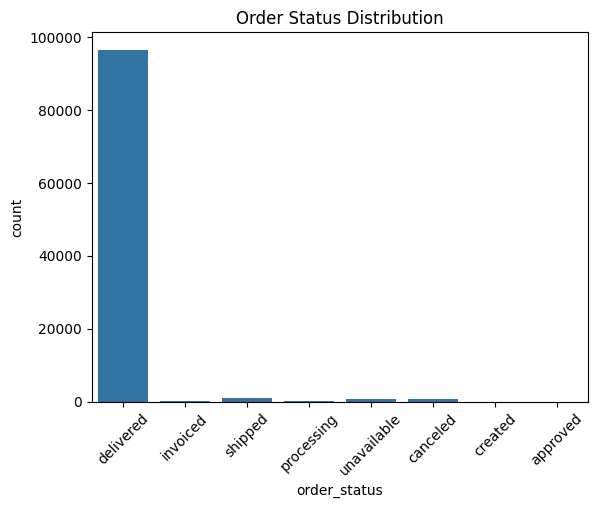

In [12]:
sns.countplot(data=df, x="order_status")
plt.xticks(rotation=45)
plt.title("Order Status Distribution")

Text(0.5, 1.0, 'Orders by Month')

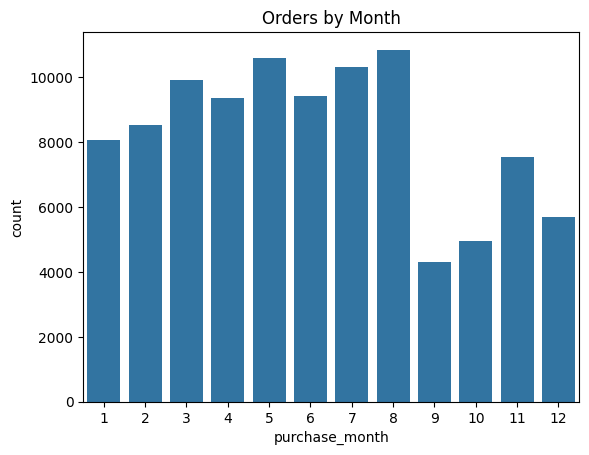

In [13]:
sns.countplot(data=df, x="purchase_month")
plt.title("Orders by Month")

Text(0.5, 1.0, 'Delivery Days Distribution')

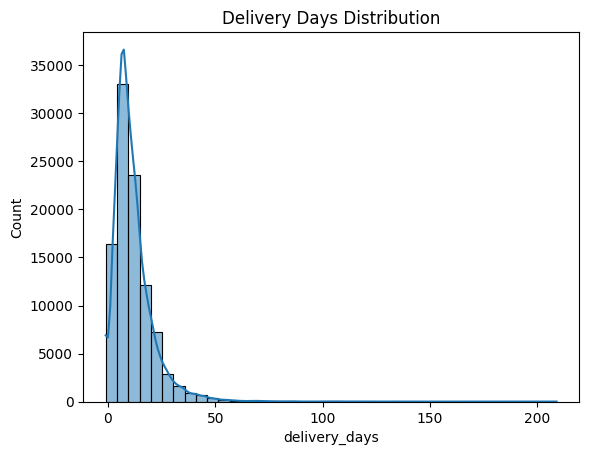

In [14]:
sns.histplot(df["delivery_days"], bins=40, kde=True)
plt.title("Delivery Days Distribution")

In [15]:
df["late_delivery"] = (df["delay_vs_estimate"] > 0).astype(int)

df.shape

(99441, 46)

Text(0.5, 1.0, 'Late Delivery Distribution')

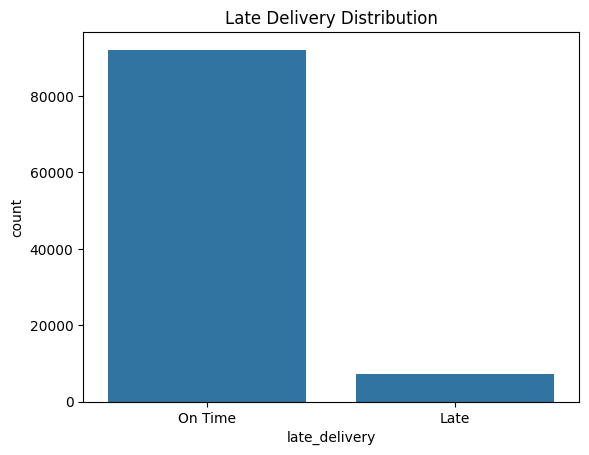

In [16]:
sns.countplot(data=df, x="late_delivery")
plt.xticks([0,1],["On Time","Late"])
plt.title("Late Delivery Distribution")

Text(0.5, 1.0, 'Review Score by Delivery Status')

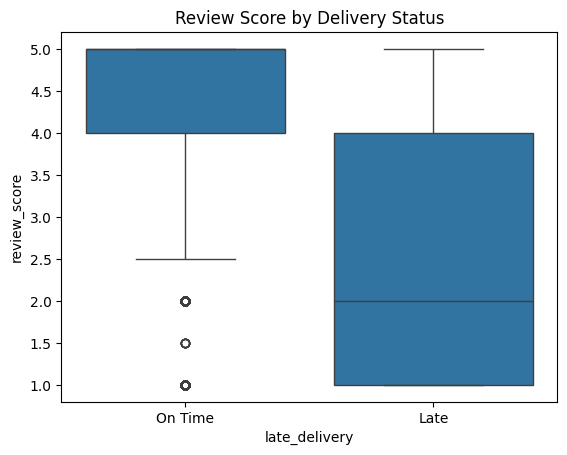

In [17]:
sns.boxplot(data=df, x="late_delivery", y="review_score")
plt.xticks([0,1],["On Time","Late"])
plt.title("Review Score by Delivery Status")

Text(0.5, 1.0, 'Top Customer States')

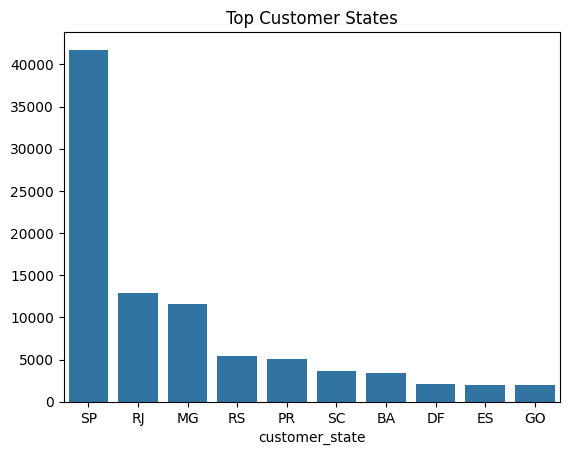

In [18]:
top_states = df["customer_state"].value_counts().head(10)

sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top Customer States")

Text(0.5, 1.0, 'Payment Value by Method')

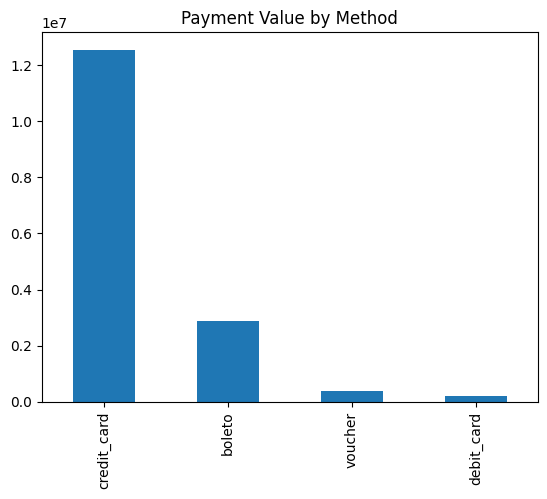

In [19]:
pay = ["credit_card","boleto","voucher","debit_card"]

df[pay].sum().plot(kind="bar")
plt.title("Payment Value by Method")

# Predicting Late Delivery Risk in E-Commerce Orders

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

In [22]:
df["late_delivery"] = (df["delay_vs_estimate"] > 0).astype(int)

In [23]:
df["late_delivery"].value_counts()

late_delivery
0    92133
1     7308
Name: count, dtype: int64

In [24]:
features = [
    "total_product_value",
    "total_freight",
    "total_items",
    "total_sellers",
    "payment_value",
    "payment_installments",
    "credit_card",
    "boleto",
    "voucher",
    "debit_card",
    "purchase_month",
    "purchase_day",
    "purchase_hour",
    "customer_state",
    "product_category_name_english",
    "estimated_days"
]

X = df[features]
y = df["late_delivery"]

In [25]:
num_cols = X.select_dtypes(include=["int64","int32","float64"]).columns
cat_cols = X.select_dtypes(include=["object","string"]).columns

In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [27]:
model = Pipeline([
    ("prep", preprocessor),
    ("rf", RandomForestClassifier(n_estimators=250, max_depth=12, class_weight="balanced", 
        random_state=42, n_jobs=-1
    ))
])

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

In [29]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spar

In [30]:
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

In [31]:
print("\nAccuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:\n", (confusion_matrix(y_test, pred)))
print("\nROC AUC:", roc_auc_score(y_test, prob))
print("\nClassification Report:\n")
print(classification_report(y_test, pred))


Accuracy: 0.7598672633113781

Confusion Matrix:
 [[14259  4168]
 [  608   854]]

ROC AUC: 0.7424315357742834

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.77      0.86     18427
           1       0.17      0.58      0.26      1462

    accuracy                           0.76     19889
   macro avg       0.56      0.68      0.56     19889
weighted avg       0.90      0.76      0.81     19889



In [32]:
import pickle

In [35]:
with open("model/late_delivery_model.pkl", "wb") as f:
    pickle.dump(model, f)